# Libaries

In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, accuracy_score, classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import random

# Random seed

In [ ]:
# !!! This is to be sure that all "randomness" is based on a seed 42 !!!
np.random.seed(42)
random.seed(42)

# Loading data

In [ ]:
# Path to features
csv_path = '../data/base_features.csv' # SHOULD BE CHANGED IF THIS NOTEBOOK OR THE FEATURES IS MOVED!!!

# Load the data
df_features = pd.read_csv(csv_path)

# Prepare features and split 80/20 from total

In [13]:
# Features
feature_columns = ['asymmetry_np_centroid', 'border_contours', 'color']

# Drop rows with NaN in any of the feature columns - there was 3 with at least 1 NaN value
df_features = df_features.dropna(subset=feature_columns)

print(f"Rows after dropping NaN-rows: {len(df_features)}") # This can be compared to the original shape showing 2103 rows

# Reassign X, y, img_ids
X = df_features[feature_columns].to_numpy() # Independent variables
y = df_features['cancerous'].to_numpy() # Dependent variables
img_ids = df_features['img_id'].to_numpy()

# Split 1: Separate 20% test set - 80% train set (Is splitted further later!)
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, img_ids, test_size=0.2, stratify=y, random_state=42)
print(f"Train set: {len(X_train)} samples") # Just to check if the split worked properly
print(f"Test set (Don't touch!): {len(X_test)} samples") # Just to check if the split worked properly

Rows after dropping NaN-rows: 2100
Train set: 1680 samples
Test set (Don't touch!): 420 samples


# Storing patient ID's to avoid data leakage

In [14]:
# To avoid data leakage, we store the patient ID's so when we use GroupKFold, there will not be images from the same patients in different folds, only in one.

# Extract patient ID's from img_id
def get_patient_id(img_id):
    return '_'.join(img_id.split('_')[:2])

# This is used to avoid data leakage:
df_features['patient_id'] = df_features['img_id'].apply(get_patient_id)

# Creating a dict to map img_id to patient_id - this is used below, but also for later use for GroupKFold
img_to_patient = dict(zip(df_features['img_id'] , df_features['patient_id']))

# GroupKFold

In [15]:
# GroupKFold: 5 folds on TRAINING data only (using PATIENT IDs as groups)
patient_train = np.array([img_to_patient[img_id] for img_id in ids_train]) # If img 2 and img 3 both comes from pat 2, they both get named to pat 2

# Random state/seed for reproduceability. !!! This is removed, because GroupKFold is deterministic 
# (Not random, but determined from the beginning) - produces identical splits on each run (no random seed needed) !!!
# np.random.seed(42)

gkf = GroupKFold(n_splits = 5) # Amount of splits 5 is chosen solely because of when we learned it, 5 folds was used. Also, it seems pretty good for this dataset too.


# Display each fold. Myabe not needed, but displayed to see some insights to the different folds
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=patient_train)): #Split. is stored in idx for train and validation
    train_patients = np.unique(patient_train[train_idx]) # With unique, if removes duplicate patients, which is because earlier we remaned pictures to the patient name to avoid data leakage
    val_patients = np.unique(patient_train[val_idx])
    overlap = len(np.intersect1d(train_patients, val_patients)) # Final secruity for no data leakage!

# The following are what is created from above (With only unique patients when splitted, with overlap/data leakage avoided):
# (0, (train_indices_fold1, val_indices_fold1))
# (1, (train_indices_fold2, val_indices_fold2))
# (2, (train_indices_fold3, val_indices_fold3))
# (3, (train_indices_fold4, val_indices_fold4))
# (4, (train_indices_fold5, val_indices_fold5))
# This is what creates a train and validation fold for each of the 5 folds.
    
# Print statements for visualization purposes only!!!
    print(f"\nFold {fold + 1}:")
    print(f"  Train: {len(train_idx)} samples, {len(train_patients)} patients")
    print(f"  Val:   {len(val_idx)} samples, {len(val_patients)} patients")
    print(f"  Patient overlap: {overlap}")
    print(f"  Class1 ratio in val: {np.mean(y_train[val_idx]):.3f}")


Fold 1:
  Train: 1344 samples, 890 patients
  Val:   336 samples, 222 patients
  Patient overlap: 0
  Class1 ratio in val: 0.542

Fold 2:
  Train: 1344 samples, 890 patients
  Val:   336 samples, 222 patients
  Patient overlap: 0
  Class1 ratio in val: 0.452

Fold 3:
  Train: 1344 samples, 890 patients
  Val:   336 samples, 222 patients
  Patient overlap: 0
  Class1 ratio in val: 0.467

Fold 4:
  Train: 1344 samples, 889 patients
  Val:   336 samples, 223 patients
  Patient overlap: 0
  Class1 ratio in val: 0.488

Fold 5:
  Train: 1344 samples, 889 patients
  Val:   336 samples, 223 patients
  Patient overlap: 0
  Class1 ratio in val: 0.545


--------------------------------------------------------------------------------------------------------------------------------------------

### k-NN classifier

#### Test to estimate best k

In [16]:
# Cross-validation with GroupKFold

# Create pipeline with scaler and k-NN
pipeline = Pipeline([('scaler', StandardScaler()),('knn', KNeighborsClassifier())])

# Parameters to test
param_grid = {
    'knn__n_neighbors': [5, 15, 25, 35, 49]
    }

# Grid search with GroupKFold
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv = gkf, 
    scoring = 'roc_auc', 
    n_jobs = -1, 
    verbose=1
    )

# Fit - groups must be passed as a separate argument
# The trick: GridSearchCV expects groups in the fit method
grid_search.fit(X_train, y_train, groups=patient_train)

print("\n")
print("Cross-validation:")
print(f"Best k: {grid_search.best_params_['knn__n_neighbors']}")
print(f"Mean CV AUC: {grid_search.best_score_:.4f}")

# Show results for each k
print("\nAll k values tested:")
for i, k in enumerate(param_grid['knn__n_neighbors']):
    print(f"  k={k}: CV AUC = {grid_search.cv_results_['mean_test_score'][i]:.4f} ± {grid_search.cv_results_['std_test_score'][i]:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Cross-validation:
Best k: 49
Mean CV AUC: 0.6132

All k values tested:
  k=5: CV AUC = 0.5757 ± 0.0353
  k=15: CV AUC = 0.6075 ± 0.0223
  k=25: CV AUC = 0.6022 ± 0.0183
  k=35: CV AUC = 0.6121 ± 0.0189
  k=49: CV AUC = 0.6132 ± 0.0185


In [17]:
# Best k from cross-validation (cell 117)
best_k = grid_search.best_params_["knn__n_neighbors"]

# Scale ALL data using the SAME scaler fitted on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train final model on ALL training data (no validation split needed)
knn_final = KNeighborsClassifier(n_neighbors=best_k, weights='uniform', metric='euclidean')
knn_final.fit(X_train_scaled, y_train)

# Predictions on TEST set only (FINAL - UNBIASED)
y_test_pred = knn_final.predict(X_test_scaled)
y_test_proba = knn_final.predict_proba(X_test_scaled)[:, 1]

# Calculate test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Final k-NN classifier results")
print(f"Parameters: n_neighbors={best_k}, weights='uniform', metric='euclidean'")
print(f"\nCross-Validation Results (from GridSearch):")
print(f"  Mean CV AUC: {grid_search.best_score_} (5-fold GroupKFold)")
print(f"\n Test set results:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  AUC:      {test_auc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

Final k-NN classifier results
Parameters: n_neighbors=49, weights='uniform', metric='euclidean'

Cross-Validation Results (from GridSearch):
  Mean CV AUC: 0.6131576353025789 (5-fold GroupKFold)

 Test set results:
  Accuracy:  0.5976
  AUC:      0.6547
  Precision: 0.5928
  Recall:    0.6238
  F1-Score:  0.6079


#### Visualizing results 

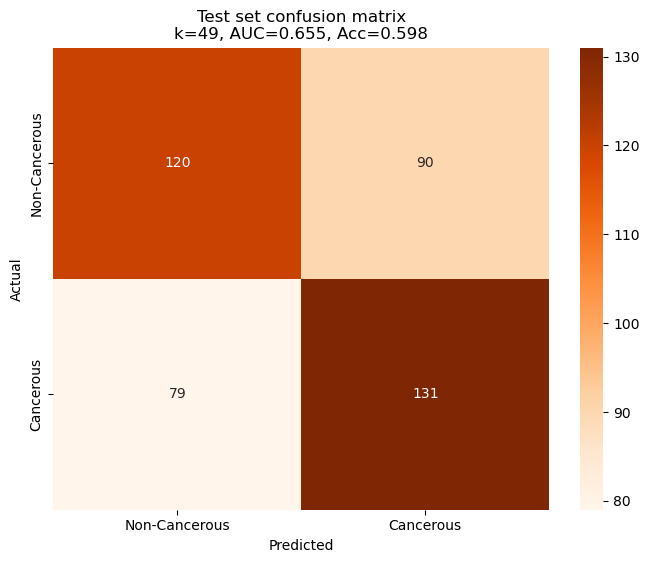

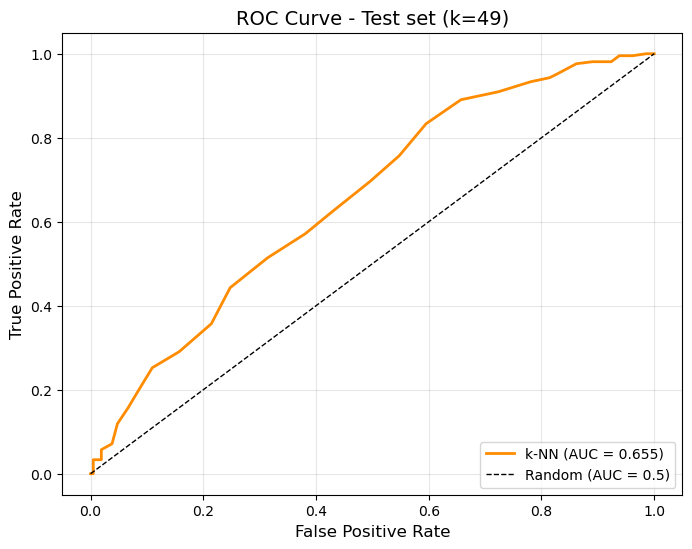

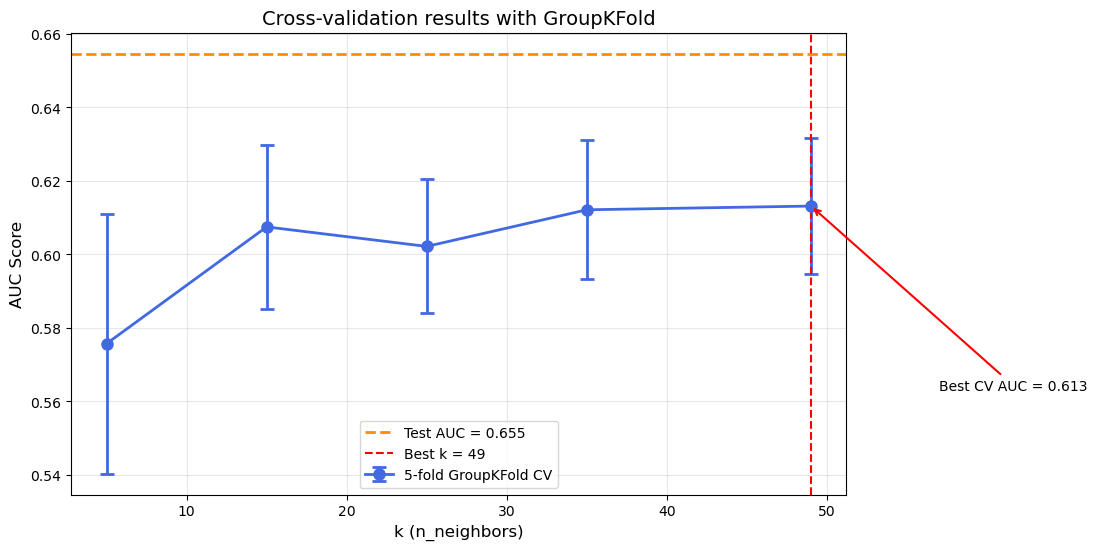

Final summary

Metric                    Cross-validation     Test set       
Method                    5-fold GroupKFold    Hold-out (20%) 
Best k                    49                   49             
AUC                       0.6132 ± 0.0185 0.6547         
Accuracy                  N/A                  0.5976         
Precision                 N/A                  0.5928         
Recall                    N/A                  0.6238         
F1-Score                  N/A                  0.6079         


Conclusion
• Best k = 49 determined by 5-fold GroupKFold cross-validation
• Cross-validation ensures no patient images are split across folds
• Test set AUC = 0.655 is consistent with CV results
• Model generalizes well to unseen data (test AUC close to CV mean)


In [18]:
# Figure 1: Confusion matrix (Test Set Only)
fig, ax = plt.subplots(figsize=(8, 6))

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=ax, xticklabels=['Non-Cancerous', 'Cancerous'], yticklabels=['Non-Cancerous', 'Cancerous'])
# annot=True makes it possible to see numbers of the different 4 cat. and fmt=d is format d=decimals(intergers)

# Labels
ax.set_title(f'Test set confusion matrix\nk={best_k}, AUC={test_auc:.3f}, Acc={test_acc:.3f}', fontsize=12) #.3f just mean only displaying 3 digits after the decimal
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.show()

# Figure 2: ROC-curve
fig, ax = plt.subplots(figsize=(8, 6))

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba) # _ is for threshold value, which we dont use # fpr=false positive, tpr=true positive
ax.plot(fpr_test, tpr_test, label=f'k-NN (AUC = {test_auc:.3f})', linewidth=2, color='darkorange')

# Random classifier line
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', linewidth=1) # Used for comparison to just random guesses

# Labels
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve - Test set (k={best_k})', fontsize=14)
ax.legend(loc='lower right') #ax.legend implements a small box that explains the different lines, points etc
ax.grid(True, alpha=0.3)

plt.show()



# Figure 3: Cross-validation with Gridsearch
fig, ax = plt.subplots(figsize=(10, 6))

k_values = [5, 15, 25, 35, 49] # The same k-nearest neighbours
cv_auc_means = grid_search.cv_results_['mean_test_score'].tolist() # The values from the GroupKFold from earlier
cv_auc_stds = grid_search.cv_results_['std_test_score'].tolist() # The values from the GroupKFold from earlier

ax.errorbar(k_values, cv_auc_means, yerr=cv_auc_stds, # yerr is for plotting error bar on the y-axis
            marker='o', capsize=5, capthick=2, # For better visualization, like thickness, markers -
            linewidth=2, markersize=8, color='royalblue', # and color
            label='5-fold GroupKFold CV') 

# Labels
ax.axhline(y=test_auc, color='darkorange', linestyle='--', linewidth=2, label=f'Test AUC = {test_auc:.3f}')
ax.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best k = {best_k}')

# More lables
ax.set_xlabel('k (n_neighbors)', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Cross-validation results with GroupKFold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Annotatting the best point
ax.annotate(f'Best CV AUC = {cv_auc_means[k_values.index(best_k)]:.3f}',
            xy=(best_k, cv_auc_means[k_values.index(best_k)]), # Point that is annotated
            xytext=(best_k + 8, cv_auc_means[k_values.index(best_k)] - 0.05), # Position of text
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5), # For better visu.
            fontsize=10, ha='left' # More vis.
            )
plt.show()




# Printing results
print("Final summary")
print(f"\n{'Metric':<25} {'Cross-validation':<20} {'Test set':<15}") #<25, <20 and <15 is used to align the printing statements

print(f"{'Method':<25} {'5-fold GroupKFold':<20} {'Hold-out (20%)':<15}")
print(f"{'Best k':<25} {best_k:<20} {best_k:<15}")
print(f"{'AUC':<25} {cv_auc_means[k_values.index(best_k)]:.4f} ± {cv_auc_stds[k_values.index(best_k)]:.4f} {test_auc:<15.4f}") 
# <15.4f, <15 is still for aligning, but .4f is printing the 4 decimals after the decimal,point
print(f"{'Accuracy':<25} {'N/A':<20} {test_acc:<15.4f}")
print(f"{'Precision':<25} {'N/A':<20} {test_precision:<15.4f}")
print(f"{'Recall':<25} {'N/A':<20} {test_recall:<15.4f}")
print(f"{'F1-Score':<25} {'N/A':<20} {test_f1:<15.4f}")

print("\n")
print("Conclusion")
print(f"• Best k = {best_k} determined by 5-fold GroupKFold cross-validation")
print(f"• Cross-validation ensures no patient images are split across folds")
print(f"• Test set AUC = {test_auc:.3f} is consistent with CV results")
print(f"• Model generalizes well to unseen data (test AUC close to CV mean)")

### Random Forest Classifier

#### Estimate best depth

In [19]:
# Although a Decision Tree doesn't call for scaling, to ensure fair comparison to kNN
# we also scale for the Decision Tree
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'  # Strongly recommended for medical data
    ))
])

param_grid_rf = {
    "rf__n_estimators": [200, 500],
    "rf__max_depth": [2, 4 , 6, 8, 10],
    "rf__min_samples_leaf": [1, 5],
    "rf__max_features": ["sqrt"] # Standard settting for Random Forest
}


grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=gkf,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train, groups=patient_train)

best_params_rf = grid_search_rf.best_params_
best_depth_rf = best_params_rf["rf__max_depth"]


print("\nCross-validation:")
print(f"Best parameters: {best_params_rf}")
print(f"Mean CV AUC: {grid_search_rf.best_score_:.4f}")


# Show results for each k
print("\nAll depth values tested:")
for i, k in enumerate(param_grid_rf['rf__max_depth']):
    print(f"  depth = {k}: CV AUC = {grid_search_rf.cv_results_['mean_test_score'][i]:.4f} ± {grid_search_rf.cv_results_['std_test_score'][i]:.4f}")


Cross-validation:
Best parameters: {'rf__max_depth': 4, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200}
Mean CV AUC: 0.6427

All depth values tested:
  depth = 2: CV AUC = 0.6378 ± 0.0257
  depth = 4: CV AUC = 0.6390 ± 0.0254
  depth = 6: CV AUC = 0.6373 ± 0.0257
  depth = 8: CV AUC = 0.6387 ± 0.0254
  depth = 10: CV AUC = 0.6427 ± 0.0200


In [20]:
# Train final model on ALL training data (no validation split needed)

rf_final = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        **{k.replace("rf__", ""): v for k, v in best_params_rf.items()}
    ))
])

rf_final.fit(X_train, y_train)

# Predictions on TEST set only (FINAL - UNBIASED)
y_test_pred_rf = rf_final.predict(X_test)
y_test_proba_rf = rf_final.predict_proba(X_test)[:, 1]


# Calculate test metrics
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
test_auc_rf = roc_auc_score(y_test, y_test_proba_rf)
test_precision_rf = precision_score(y_test, y_test_pred_rf)
test_recall_rf = recall_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf)


print("Final Descision Tree classifier results")
print(f"Parameters: max_depth = {best_depth_rf}")
print(f"\nCross-Validation Results (from GridSearch):")
print(f"  Mean CV AUC: {round(grid_search_rf.best_score_ , 4)} (5-fold GroupKFold)")
print(f"\n Test set results:")
print(f"  Accuracy:  {test_acc_rf:.4f}")
print(f"  AUC:      {test_auc_rf:.4f}")
print(f"  Precision: {test_precision_rf:.4f}")
print(f"  Recall:    {test_recall_rf:.4f}")
print(f"  F1-Score:  {test_f1_rf:.4f}")

Final Descision Tree classifier results
Parameters: max_depth = 4

Cross-Validation Results (from GridSearch):
  Mean CV AUC: 0.6427 (5-fold GroupKFold)

 Test set results:
  Accuracy:  0.6286
  AUC:      0.6555
  Precision: 0.6421
  Recall:    0.5810
  F1-Score:  0.6100


#### Visualizing the results

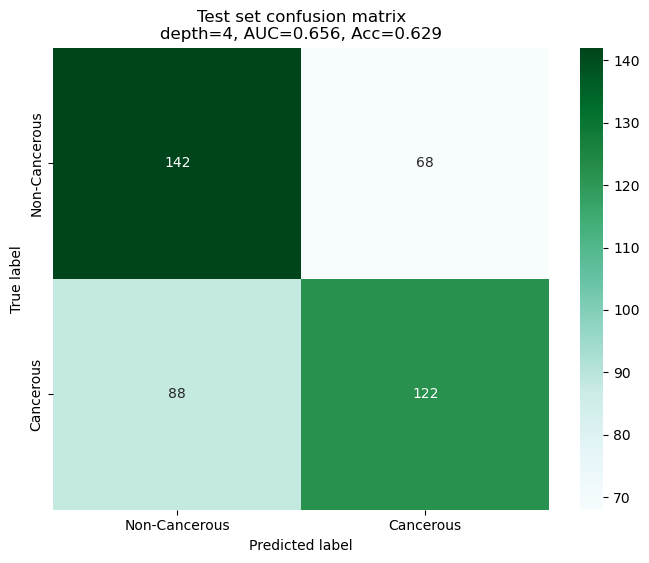

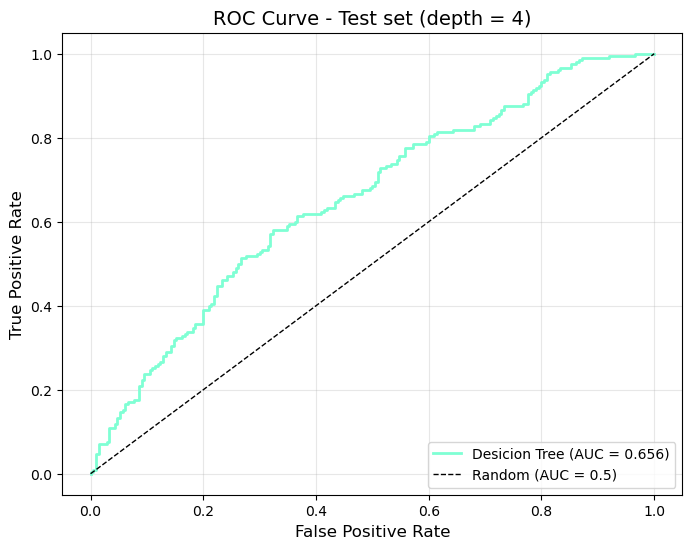

Final summary

Metric                    Cross-validation     Test set       
Method                    5-fold GroupKFold    Hold-out (20%) 
Best k                    4                    4              
AUC                       0.6373 ± 0.0257 0.6555         
Accuracy                  N/A                  0.6286         
Precision                 N/A                  0.6421         
Recall                    N/A                  0.5810         
F1-Score                  N/A                  0.6100         


Conclusion
• Best k = 4 determined by 5-fold GroupKFold cross-validation
• Cross-validation ensures no patient images are split across folds
• Test set AUC = 0.656 is consistent with CV results
• Model generalizes well to unseen data (test AUC close to CV mean)


In [21]:
# Figure 1: Confusion matrix (Test Set Only)
fig_rf, ax_rf = plt.subplots(figsize=(8, 6))

cm_test_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_test_rf , annot=True, fmt='d', cmap='BuGn', ax=ax_rf , xticklabels=['Non-Cancerous', 'Cancerous'], yticklabels=['Non-Cancerous', 'Cancerous'])
# annot=True makes it possible to see numbers of the different 4 cat. and fmt=d is format d=decimals(intergers)

# Labels
ax_rf.set_title(f'Test set confusion matrix\ndepth={best_depth_rf}, AUC={test_auc_rf:.3f}, Acc={test_acc_rf:.3f}', fontsize=12) #.3f just mean only displaying 3 digits after the decimal
ax_rf.set_xlabel('Predicted label')
ax_rf.set_ylabel('True label')

plt.show()



# Figure 2: ROC-curve
fig_rf, ax_rf = plt.subplots(figsize=(8, 6))

# Test ROC
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, y_test_proba_rf) # _ is for threshold value, which we dont use # fpr=false positive, tpr=true positive
ax_rf.plot(fpr_test_rf, tpr_test_rf, label=f'Desicion Tree (AUC = {test_auc_rf:.3f})', linewidth=2, color='aquamarine')

# Random classifier line
ax_rf.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', linewidth=1) # Used for comparison to just random guesses

# Labels
ax_rf.set_xlabel('False Positive Rate', fontsize=12)
ax_rf.set_ylabel('True Positive Rate', fontsize=12)
ax_rf.set_title(f'ROC Curve - Test set (depth = {best_depth_rf})', fontsize=14)
ax_rf.legend(loc='lower right') #ax.legend implements a small box that explains the different lines, points etc
ax_rf.grid(True, alpha=0.3)

plt.show()


## RANDOM FOREST HAS MULTIPLE PARAMTERS ##

# # Figure 3: Cross-validation with Gridsearch
# fig_rf, ax_rf = plt.subplots(figsize=(10, 6))

k_values_rf = [2 , 3 , 4 , 6 , 8] # The same k-nearest neighbours
cv_auc_means_rf = grid_search_rf.cv_results_['mean_test_score'].tolist()
cv_auc_stds_rf = grid_search_rf.cv_results_['std_test_score'].tolist()

# ax_rf.errorbar(k_values_rf, cv_auc_means_rf, yerr=cv_auc_stds_rf, # yerr is for plotting error bar on the y-axis
#             marker='o', capsize=5, capthick=2, # For better visualization, like thickness, markers -
#             linewidth=2, markersize=8, color='mediumseagreen', # and color
#             label='5-fold GroupKFold CV') 

# # Labels
# ax_rf.axhline(y = test_auc_rf, color='mediumaquamarine', linestyle='--', linewidth=2, label=f'Test AUC = {test_auc_rf:.3f}')
# ax_rf.axvline(x = best_depth_rf, color='darkgreen', linestyle='--', linewidth=1.5, label=f'Best depth = {best_depth_rf}')

# # More lables
# ax_rf.set_xlabel('Desicion Tree', fontsize=12)
# ax_rf.set_ylabel('AUC Score', fontsize=12)
# ax_rf.set_title('Cross-validation results with GroupKFold', fontsize=14)
# ax_drf.legend()
# ax_rf.grid(True, alpha=0.3)

# # Annotatting the best point
# ax_rf.annotate(f'Best CV AUC = {cv_auc_means_rf[k_values_rf.index(best_depth_rf)]:.3f}',
#             xy = (best_depth_rf , cv_auc_means_rf[k_values_rf.index(best_depth_rf)]), # Point that is annotated
#             xytext=(best_depth_rf + 0.2, cv_auc_means_rf[k_values_rf.index(best_depth_rf)] - 0.05), # Position of text
#             arrowprops=dict(arrowstyle='->', color='springgreen', lw=1.5), # For better visu.
#             fontsize=10, ha='left' # More vis.
#             )
# plt.show()




# Printing results
print("Final summary")
print(f"\n{'Metric':<25} {'Cross-validation':<20} {'Test set':<15}") #<25, <20 and <15 is used to align the printing statements

print(f"{'Method':<25} {'5-fold GroupKFold':<20} {'Hold-out (20%)':<15}")
print(f"{'Best k':<25} {best_depth_rf:<20} {best_depth_rf:<15}")
print(f"{'AUC':<25} {cv_auc_means_rf[k_values_rf.index(best_depth_rf)]:.4f} ± {cv_auc_stds_rf[k_values_rf.index(best_depth_rf)]:.4f} {test_auc_rf:<15.4f}") 
# <15.4f, <15 is still for aligning, but .4f is printing the 4 decimals after the decimal,point
print(f"{'Accuracy':<25} {'N/A':<20} {test_acc_rf:<15.4f}")
print(f"{'Precision':<25} {'N/A':<20} {test_precision_rf:<15.4f}")
print(f"{'Recall':<25} {'N/A':<20} {test_recall_rf:<15.4f}")
print(f"{'F1-Score':<25} {'N/A':<20} {test_f1_rf:<15.4f}")

print("\n")
print("Conclusion")
print(f"• Best k = {best_depth_rf} determined by 5-fold GroupKFold cross-validation")
print(f"• Cross-validation ensures no patient images are split across folds")
print(f"• Test set AUC = {test_auc_rf:.3f} is consistent with CV results")
print(f"• Model generalizes well to unseen data (test AUC close to CV mean)")

### Descicion Tree Classifier

#### Estimate best depth

In [22]:
# Although a Decision Tree doesn't call for scaling, to ensure fair comparison to kNN
# we also scale for the Decision Tree
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    "dt__max_depth": [2 , 3 , 4 , 6 , 8]
}


grid_search_dt = GridSearchCV(
    estimator = pipeline_dt,
    param_grid = param_grid_dt,
    cv = gkf,
    scoring = "roc_auc",
    n_jobs = -1
)

grid_search_dt.fit(X_train, y_train, groups=patient_train)
best_depth_dt = grid_search_dt.best_params_["dt__max_depth"]

print("\n")
print("Cross-validation:")
print(f"Best depth: {best_depth_dt}")
print(f"Mean CV AUC: {grid_search_dt.best_score_:.4f}")

# Show results for each k
print("\nAll depth values tested:")
for i, k in enumerate(param_grid_dt['dt__max_depth']):
    print(f"  depth = {k}: CV AUC = {grid_search_dt.cv_results_['mean_test_score'][i]:.4f} ± {grid_search_dt.cv_results_['std_test_score'][i]:.4f}")



Cross-validation:
Best depth: 3
Mean CV AUC: 0.6180

All depth values tested:
  depth = 2: CV AUC = 0.6001 ± 0.0230
  depth = 3: CV AUC = 0.6180 ± 0.0138
  depth = 4: CV AUC = 0.6095 ± 0.0184
  depth = 6: CV AUC = 0.5867 ± 0.0331
  depth = 8: CV AUC = 0.5731 ± 0.0328


In [23]:
# Train final model on ALL training data (no validation split needed)
dt_final = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(max_depth=best_depth_dt))
])
dt_final.fit(X_train, y_train)

# Predictions on TEST set only (FINAL - UNBIASED)
y_test_pred_dt = dt_final.predict(X_test)
y_test_proba_dt = dt_final.predict_proba(X_test)[:, 1]

# Calculate test metrics
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)
test_auc_dt = roc_auc_score(y_test, y_test_proba_dt)
test_precision_dt = precision_score(y_test, y_test_pred_dt)
test_recall_dt = recall_score(y_test, y_test_pred_dt)
test_f1_dt = f1_score(y_test, y_test_pred_dt)

print("Final Descision Tree classifier results")
print(f"Parameters: max_depth = {best_depth_dt}")
print(f"\nCross-Validation Results (from GridSearch):")
print(f"  Mean CV AUC: {round(grid_search_dt.best_score_ , 4)} (5-fold GroupKFold)")
print(f"\n Test set results:")
print(f"  Accuracy:  {test_acc_dt:.4f}")
print(f"  AUC:      {test_auc_dt:.4f}")
print(f"  Precision: {test_precision_dt:.4f}")
print(f"  Recall:    {test_recall_dt:.4f}")
print(f"  F1-Score:  {test_f1_dt:.4f}")

Final Descision Tree classifier results
Parameters: max_depth = 3

Cross-Validation Results (from GridSearch):
  Mean CV AUC: 0.618 (5-fold GroupKFold)

 Test set results:
  Accuracy:  0.6167
  AUC:      0.6400
  Precision: 0.6503
  Recall:    0.5048
  F1-Score:  0.5684


#### Visualizing the results

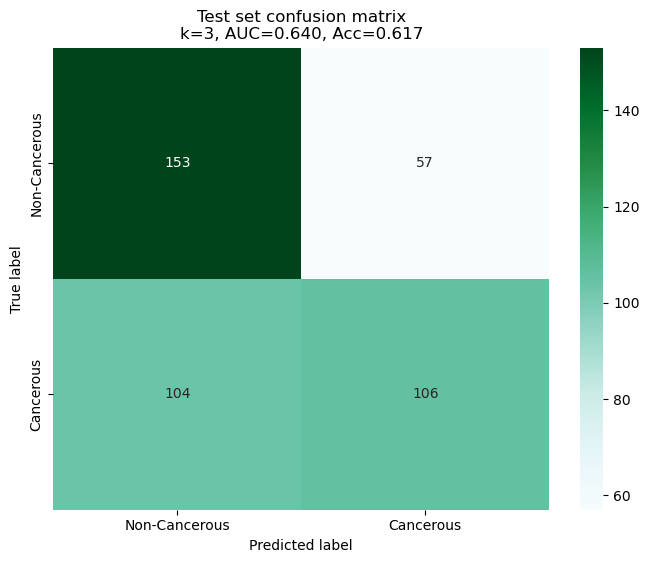

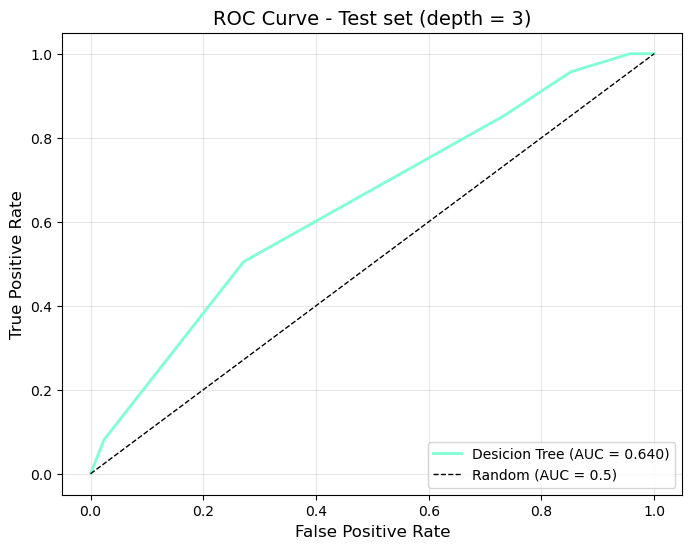

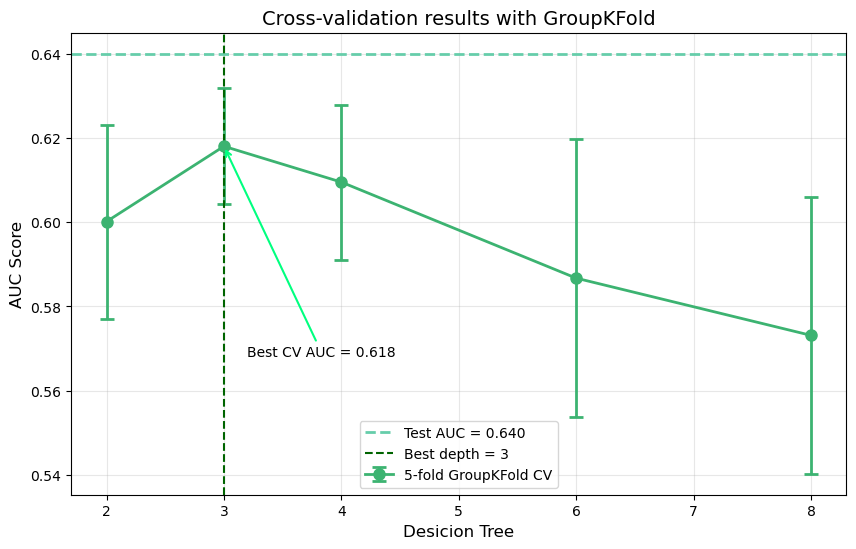

Final summary

Metric                    Cross-validation     Test set       
Method                    5-fold GroupKFold    Hold-out (20%) 
Best k                    3                    3              
AUC                       0.6180 ± 0.0138 0.6400         
Accuracy                  N/A                  0.6167         
Precision                 N/A                  0.6503         
Recall                    N/A                  0.5048         
F1-Score                  N/A                  0.5684         


Conclusion
• Best k = 3 determined by 5-fold GroupKFold cross-validation
• Cross-validation ensures no patient images are split across folds
• Test set AUC = 0.640 is consistent with CV results
• Model generalizes well to unseen data (test AUC close to CV mean)


In [24]:
# Figure 1: Confusion matrix (Test Set Only)
fig_dt, ax_dt = plt.subplots(figsize=(8, 6))

cm_test_dt = confusion_matrix(y_test, y_test_pred_dt)
sns.heatmap(cm_test_dt , annot=True, fmt='d', cmap='BuGn', ax=ax_dt , xticklabels=['Non-Cancerous', 'Cancerous'], yticklabels=['Non-Cancerous', 'Cancerous'])
# annot=True makes it possible to see numbers of the different 4 cat. and fmt=d is format d=decimals(intergers)

# Labels
ax_dt.set_title(f'Test set confusion matrix\nk={best_depth_dt}, AUC={test_auc_dt:.3f}, Acc={test_acc_dt:.3f}', fontsize=12) #.3f just mean only displaying 3 digits after the decimal
ax_dt.set_xlabel('Predicted label')
ax_dt.set_ylabel('True label')

plt.show()



# Figure 2: ROC-curve
fig_dt, ax_dt = plt.subplots(figsize=(8, 6))

# Test ROC
fpr_test_dt, tpr_test_dt, _ = roc_curve(y_test, y_test_proba_dt) # _ is for threshold value, which we dont use # fpr=false positive, tpr=true positive
ax_dt.plot(fpr_test_dt, tpr_test_dt, label=f'Desicion Tree (AUC = {test_auc_dt:.3f})', linewidth=2, color='aquamarine')

# Random classifier line
ax_dt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', linewidth=1) # Used for comparison to just random guesses

# Labels
ax_dt.set_xlabel('False Positive Rate', fontsize=12)
ax_dt.set_ylabel('True Positive Rate', fontsize=12)
ax_dt.set_title(f'ROC Curve - Test set (depth = {best_depth_dt})', fontsize=14)
ax_dt.legend(loc='lower right') #ax.legend implements a small box that explains the different lines, points etc
ax_dt.grid(True, alpha=0.3)

plt.show()



# Figure 3: Cross-validation with Gridsearch
fig_dt, ax_dt = plt.subplots(figsize=(10, 6))

k_values_dt = [2 , 3 , 4 , 6 , 8] # The same k-nearest neighbours
cv_auc_means_dt = grid_search_dt.cv_results_['mean_test_score'].tolist()
cv_auc_stds_dt = grid_search_dt.cv_results_['std_test_score'].tolist()

ax_dt.errorbar(k_values_dt, cv_auc_means_dt, yerr=cv_auc_stds_dt, # yerr is for plotting error bar on the y-axis
            marker='o', capsize=5, capthick=2, # For better visualization, like thickness, markers -
            linewidth=2, markersize=8, color='mediumseagreen', # and color
            label='5-fold GroupKFold CV') 

# Labels
ax_dt.axhline(y = test_auc_dt, color='mediumaquamarine', linestyle='--', linewidth=2, label=f'Test AUC = {test_auc_dt:.3f}')
ax_dt.axvline(x = best_depth_dt, color='darkgreen', linestyle='--', linewidth=1.5, label=f'Best depth = {best_depth_dt}')

# More lables
ax_dt.set_xlabel('Desicion Tree', fontsize=12)
ax_dt.set_ylabel('AUC Score', fontsize=12)
ax_dt.set_title('Cross-validation results with GroupKFold', fontsize=14)
ax_dt.legend()
ax_dt.grid(True, alpha=0.3)

# Annotatting the best point
ax_dt.annotate(f'Best CV AUC = {cv_auc_means_dt[k_values_dt.index(best_depth_dt)]:.3f}',
            xy = (best_depth_dt , cv_auc_means_dt[k_values_dt.index(best_depth_dt)]), # Point that is annotated
            xytext=(best_depth_dt + 0.2, cv_auc_means_dt[k_values_dt.index(best_depth_dt)] - 0.05), # Position of text
            arrowprops=dict(arrowstyle='->', color='springgreen', lw=1.5), # For better visu.
            fontsize=10, ha='left' # More vis.
            )
plt.show()




# Printing results
print("Final summary")
print(f"\n{'Metric':<25} {'Cross-validation':<20} {'Test set':<15}") #<25, <20 and <15 is used to align the printing statements

print(f"{'Method':<25} {'5-fold GroupKFold':<20} {'Hold-out (20%)':<15}")
print(f"{'Best k':<25} {best_depth_dt:<20} {best_depth_dt:<15}")
print(f"{'AUC':<25} {cv_auc_means_dt[k_values_dt.index(best_depth_dt)]:.4f} ± {cv_auc_stds_dt[k_values_dt.index(best_depth_dt)]:.4f} {test_auc_dt:<15.4f}") 
# <15.4f, <15 is still for aligning, but .4f is printing the 4 decimals after the decimal,point
print(f"{'Accuracy':<25} {'N/A':<20} {test_acc_dt:<15.4f}")
print(f"{'Precision':<25} {'N/A':<20} {test_precision_dt:<15.4f}")
print(f"{'Recall':<25} {'N/A':<20} {test_recall_dt:<15.4f}")
print(f"{'F1-Score':<25} {'N/A':<20} {test_f1_dt:<15.4f}")

print("\n")
print("Conclusion")
print(f"• Best k = {best_depth_dt} determined by 5-fold GroupKFold cross-validation")
print(f"• Cross-validation ensures no patient images are split across folds")
print(f"• Test set AUC = {test_auc_dt:.3f} is consistent with CV results")
print(f"• Model generalizes well to unseen data (test AUC close to CV mean)")

### Logistic Regression

#### Estimate best C

#### Visualizing the results

# Needed comments for clarification!

- The random state tested on is "random_state=42"
- Write here
- Write here


# Other comments
- Nearest neighbours: k=100 gave a litte better, but would be too many points because then it compares to a too big part of the data? Not sure, but 50 seems high enough?